<!-- ARTHASAATHI-PROVENANCE -->
> ## ⚠️ This notebook is demo evidence, not the running system
>
> The logic below was migrated to **`ml/src/decision/deliberation.py`** and that module is what the application actually executes.
>
> **Role in the system:** Decision Layer -> Deliberation Engine & Master Judge
>
> This notebook is preserved because its stored outputs are the record of the original analysis. **Editing the cells below will not change the system's behaviour** — change the module and its tests instead.
>
> Tests for this logic live under `tests/`, and every agent is covered by the cross-cutting contract suite in `tests/common/test_contracts.py`.


In [22]:
# !pip install langgraph langchain langchain-openai python-dotenv pandas matplotlib

In [23]:
from typing import TypedDict
from dotenv import load_dotenv

import pandas as pd
import matplotlib.pyplot as plt

from langgraph.graph import StateGraph, START, END

from langchain_openai import ChatOpenAI

load_dotenv()

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "mistralai/Codestral-22B-v0.1"
)

def count_tokens(text):
    return len(tokenizer.encode(text))

python-dotenv could not parse statement starting at line 6


In [24]:
from openai import OpenAI
import os

llm = OpenAI(
    base_url="https://api.llm7.io/v1/",
    api_key=os.getenv("LLM7_API_KEY")
)

In [25]:
class FinancialState(TypedDict):

    query:str

    conservative_advice:str
    growth_advice:str
    value_advice:str

    conservative_critique:str
    growth_critique:str
    value_critique:str

    conservative_tokens:int
    growth_tokens:int
    value_tokens:int

    conservative_prompt_tokens:int
    growth_prompt_tokens:int
    value_prompt_tokens:int

    conservative_completion_tokens:int
    growth_completion_tokens:int
    value_completion_tokens:int

    judge_tokens:int

    final_decision:str

In [26]:
def extract_tokens(response):

    usage = getattr(response, "usage", None)

    if usage is None:
        return {
            "prompt": 0,
            "completion": 0,
            "total": 0
        }

    return {
        "prompt": usage.prompt_tokens,
        "completion": usage.completion_tokens,
        "total": usage.total_tokens
    }

In [27]:
def conservative_agent(state):

    print("\n===== CONSERVATIVE =====")

    prompt = f"""
    User Query:
    {state['query']}

    Give low-risk advice.
    """

    response = llm.chat.completions.create(
     model="default",  # replace with your LLM7 model
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

    answer = response.choices[0].message.content

    print(answer[:200])

    prompt_tokens = count_tokens(prompt)
    completion_tokens = count_tokens(answer)

    total_tokens = prompt_tokens + completion_tokens

    print(total_tokens)

    return {

        "conservative_advice": answer,

        "conservative_tokens": total_tokens,

        "conservative_prompt_tokens": prompt_tokens,

        "conservative_completion_tokens": completion_tokens
    }   

In [28]:
def growth_agent(state):

    prompt = f"""
    User Query:
    {state['query']}

    Give aggressive growth advice.
    """

    response = llm.chat.completions.create(
        model="default",
        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ]
    )

    answer = response.choices[0].message.content


    prompt_tokens = count_tokens(prompt)
    completion_tokens = count_tokens(answer)

    total_tokens = prompt_tokens + completion_tokens


    
    
    print(total_tokens)

    return {

        "growth_advice": answer,

        "growth_tokens": total_tokens,

        "growth_prompt_tokens": prompt_tokens,

        "growth_completion_tokens": completion_tokens
    }

In [29]:
def value_agent(state):

    print("\n===== VALUE =====")

    prompt = f"""
    User Query:
    {state['query']}

    Give balanced investing advice.
    """

    response = llm.chat.completions.create(
    model="default",   # replace with your LLM7 model
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

    answer = response.choices[0].message.content

    total_tokens = count_tokens(prompt) + count_tokens(answer)

    print(total_tokens)

    return {

    
    "value_advice": answer,

    "value_tokens": total_tokens,

    "value_prompt_tokens": count_tokens(prompt),

    "value_completion_tokens": count_tokens(answer)

}


In [30]:
def conservative_critic(state):

    prompt = f"""
    Critique this growth strategy:

    {state['growth_advice']}
    """

    response = llm.chat.completions.create(
    model="default",  # replace with your LLM7 model
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

    answer = response.choices[0].message.content

    return {
        "conservative_critique": answer
    }

In [31]:
def growth_critic(state):

    prompt = f"""
    Critique this value strategy:

    {state['value_advice']}
    """

    response = llm.chat.completions.create(
    model="default",   # replace with your LLM7 model
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

    answer = response.choices[0].message.content

    return {
        "growth_critique": answer
    }

In [32]:
def value_critic(state):

    prompt = f"""
    Critique this conservative strategy:

    {state['conservative_advice']}
    """

    response = llm.chat.completions.create(
    model="default",   # replace with your LLM7 model
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)

    answer = response.choices[0].message.content

    return {
        "value_critique": answer
    }

In [ ]:
def judge_agent(state):

    print("\n===== JUDGE =====")

    prompt = f"""

    QUERY:
    {state['query']}

    CONSERVATIVE:
    {state['conservative_advice']}

    GROWTH:
    {state['growth_advice']}

    VALUE:
    {state['value_advice']}

    CONSERVATIVE CRITIQUE:
    {state['conservative_critique']}

    GROWTH CRITIQUE:
    {state['growth_critique']}

    VALUE CRITIQUE:
    {state['value_critique']}

    Produce final recommendation.
    """

    response = llm.chat.completions.create(
    model="default",   # replace with your LLM7 model
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ]
)
    print(response.usage)
    print(response.model_dump())
    

    answer = response.choices[0].message.content

    total_tokens = count_tokens(prompt) + count_tokens(answer)

    print(total_tokens)

    return {

        "final_decision":answer,

        "judge_tokens": total_tokens
    }



In [34]:
builder = StateGraph(FinancialState)

In [35]:
builder.add_node("conservative", conservative_agent)

builder.add_node("growth", growth_agent)

builder.add_node("value", value_agent)

builder.add_node("conservative_critic", conservative_critic)

builder.add_node("growth_critic", growth_critic)

builder.add_node("value_critic", value_critic)

builder.add_node("judge", judge_agent)

In [36]:
builder.add_edge(START,"conservative")
builder.add_edge(START,"growth")
builder.add_edge(START,"value")

builder.add_edge("growth","conservative_critic")

builder.add_edge("value","growth_critic")

builder.add_edge("conservative","value_critic")

builder.add_edge("conservative_critic","judge")
builder.add_edge("growth_critic","judge")
builder.add_edge("value_critic","judge")

builder.add_edge("judge",END)

In [37]:
graph = builder.compile()

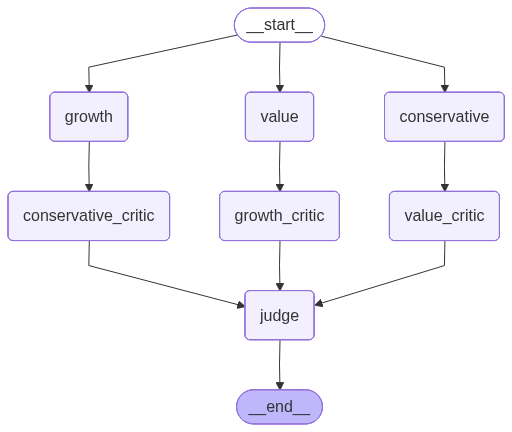

In [38]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [39]:
try:
    result = graph.invoke({
        "query": "I have ₹1 lakh. Moderate risk. 5 year horizon."
    })
except Exception as e:
    import traceback
    traceback.print_exc()


===== CONSERVATIVE =====

===== VALUE =====
748
Given your ₹1 lakh investment, moderate risk tolerance, and a 5-year horizon, here’s a **low-risk investment strategy** to balance growth with stability:

### **1. Fixed Deposits (FDs) – 30-40%**
   -
853
1124

===== JUDGE =====
None
{'id': 'chatcmpl-7236c71e-03ce-49dc-a2f9-340d40fc5866', 'choices': [{'finish_reason': 'stop', 'index': None, 'logprobs': None, 'message': {'content': 'Here’s the **final optimized conservative investment strategy** for ₹1 lakh, balancing **moderate risk**, **5-year horizon**, and **risk-adjusted returns**:\n\n---\n\n### **Recommended Portfolio Allocation (₹1 Lakh)**\n| **Asset Class**          | **Allocation** | **Example Investments**                     | **Risk Level** | **Returns (Approx.)** |\n|--------------------------|---------------|---------------------------------------------|----------------|-----------------------|\n| **Fixed Deposits (FDs)** | 20-25%        | Short-term (1-3 years) FDs (SBI, HD

In [40]:
result = graph.invoke({

    "query":
    """
    I have ₹1 lakh.
    Horizon 5 years.
    Moderate risk.
    """
})



===== CONSERVATIVE =====

===== VALUE =====
For a ₹1 lakh investment over a 5-year horizon with a **moderate risk tolerance** and a preference for **low-risk** options, here’s a balanced portfolio suggestion:

### **Recommended Allocation (Low-
731
1065
1434

===== JUDGE =====
None
{'id': 'chatcmpl-8fbed27e-429b-46b8-8156-cfdc00e0b915', 'choices': [{'finish_reason': 'stop', 'index': None, 'logprobs': None, 'message': {'content': 'Here’s the **final optimized investment recommendation** for ₹1 lakh over a **5-year horizon** with a **moderate risk tolerance**, balancing **growth, safety, and liquidity**:\n\n---\n\n### **Recommended Portfolio (Balanced Growth)**\n| **Asset Class**       | **Allocation** | **Fund/Instrument**               | **Risk**  | **Returns (Approx.)** |\n|------------------------|---------------|------------------------------------|-----------|-----------------------|\n| **Equity (Growth)**    | 40% (₹40K)    | - **Nifty 50 ETF (₹25K)**          | Low       | 12-15

In [41]:
print(result["final_decision"])

Here’s the **final optimized investment recommendation** for ₹1 lakh over a **5-year horizon** with a **moderate risk tolerance**, balancing **growth, safety, and liquidity**:

---

### **Recommended Portfolio (Balanced Growth)**
| **Asset Class**       | **Allocation** | **Fund/Instrument**               | **Risk**  | **Returns (Approx.)** |
|------------------------|---------------|------------------------------------|-----------|-----------------------|
| **Equity (Growth)**    | 40% (₹40K)    | - **Nifty 50 ETF (₹25K)**          | Low       | 12-15% p.a.           |
|                        |               | - **Mid-Cap Fund (₹10K)**         | Moderate  | 15-20% p.a.           |
|                        |               | - **Dividend ETF (₹5K)**          | Low       | 10-12% p.a.           |
| **Debt (Stability)**   | 30% (₹30K)    | - **5-Year G-Secs (₹15K)**         | Very Low  | 7-7.5% p.a.           |
|                        |               | - **AAA Corporate Bonds (₹10K)**  

          Agent  Tokens
0  Conservative     731
1        Growth    1434
2         Value    1065
3         Judge    8248

TOTAL TOKENS: 11478


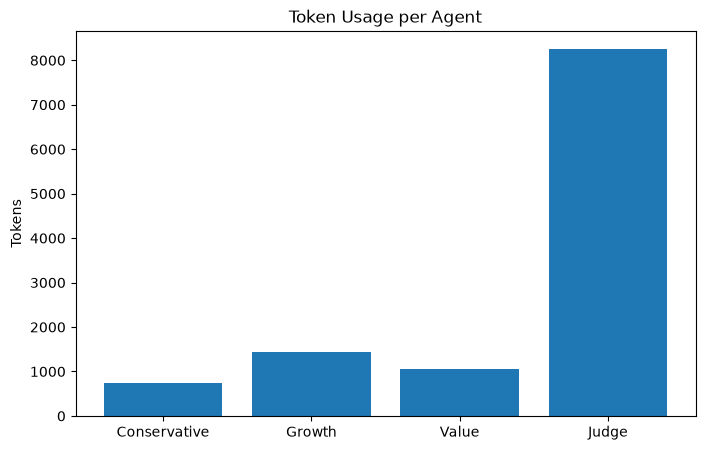

In [42]:
token_df = pd.DataFrame({

    "Agent":[
        "Conservative",
        "Growth",
        "Value",
        "Judge"
    ],

    "Tokens":[

        result["conservative_tokens"],

        result["growth_tokens"],

        result["value_tokens"],

        result["judge_tokens"]
    ]
})

print(token_df)

print(
    "\nTOTAL TOKENS:",
    token_df["Tokens"].sum()
)

plt.figure(figsize=(8,5))

plt.bar(
    token_df["Agent"],
    token_df["Tokens"]
)

plt.title(
    "Token Usage per Agent"
)

plt.ylabel(
    "Tokens"
)

plt.show()